# Model Comparison: Logistic Regression vs. Random Forest

This notebook compares the two final tuned models from this project using models saved by `run_pipeline.py`. No model fitting happens here. This notebook loads the persisted models and re-derives comparison metrics/plots on the same held-out test set used throughout.

Some comparison was performed in the model notebooks, but this notebook comparisons models more explicitly and in one place. 

In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, average_precision_score

from src.data_loader import load_features
from src.preprocessing import clean_data, encode_categoricals
from src.split import patient_split, get_features_and_target
from src.evaluate import compute_metrics

# Rebuild the test set (same deterministic pipeline as run_pipeline.py)
df = load_features()
df = clean_data(df)
train_df, test_df = patient_split(df)
X_train, y_train, ids_train = get_features_and_target(train_df)
X_test, y_test, ids_test = get_features_and_target(test_df)
X_train, X_test = encode_categoricals(X_train, X_test)

# Load saved models
final_lr = joblib.load('../../models/logistic_regression_final.joblib')
scaler = joblib.load('../../models/scaler.joblib')
final_rf = joblib.load('../../models/random_forest_final.joblib')

X_test_scaled = scaler.transform(X_test)

Loaded 101,766 rows, 54 columns.
Unique patients: 71,518

Columns with missing values:
race      2367
gender       3

Readmitted-within-30-days rate: 11.16%

  Dropped 2,423 rows with death/hospice discharge disposition.
  Dropped 3 rows with missing/invalid gender.
  Filled 2,320 missing race values with 'Unknown'.

Raw data: 101,766 encounters; Cleaned data: 99,340 encounters (2,426 dropped total).

Total encounters: 99,340 | Train: 79,462 (80.0%) | Test: 19,878 (20.0%)
Readmit rate - Full: 11.39% | Train: 11.36% | Test: 11.51%

Encoding 33 categorical columns: ['race', 'gender', 'admission_type', 'discharge_disposition', 'admission_source', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide_metformin', 'glipizide_metformin', 'glimepiride_p

In [3]:
# Compute metrics for both models on the test set
y_scores_lr = final_lr.predict_proba(X_test_scaled)[:, 1]
y_scores_rf = final_rf.predict_proba(X_test)[:, 1]

lr_metrics = compute_metrics(y_test, final_lr.predict_proba(X_test_scaled))
rf_metrics = compute_metrics(y_test, final_rf.predict_proba(X_test))

comparison_df = pd.DataFrame([lr_metrics, rf_metrics], index=["Logistic Regression", "Random Forest"])
comparison_df

,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
Logistic Regression,0.665223,0.226813,0.673961,0.184024,0.533654,0.273675,0.5
Random Forest,0.670954,0.238158,0.643727,0.181335,0.596154,0.278084,0.5


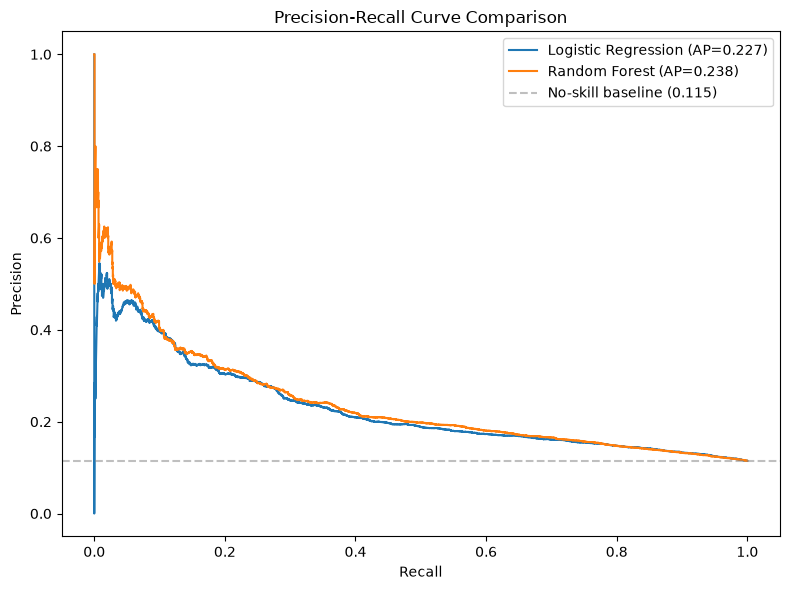

In [6]:
precisions_lr, recalls_lr, _ = precision_recall_curve(y_test, y_scores_lr)
precisions_rf, recalls_rf, _ = precision_recall_curve(y_test, y_scores_rf)

plt.figure(figsize=(8, 6))
plt.plot(recalls_lr, precisions_lr, label=f"Logistic Regression (AP={average_precision_score(y_test, y_scores_lr):.3f})")
plt.plot(recalls_rf, precisions_rf, label=f"Random Forest (AP={average_precision_score(y_test, y_scores_rf):.3f})")
plt.axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5, label=f"No-skill baseline ({y_test.mean():.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

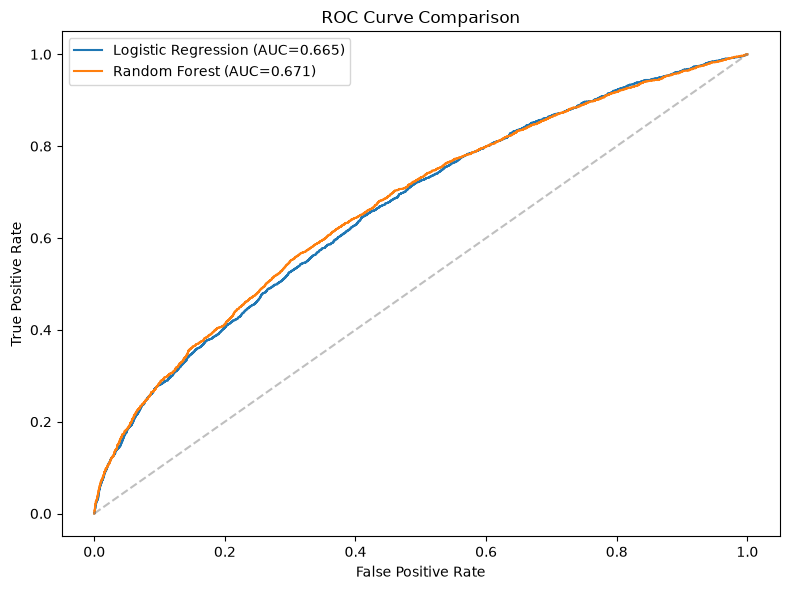

In [8]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_scores_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_scores_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_scores_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_scores_rf):.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### Threshold Comparison 

When optimizing for threshold, both models obtained an optimal threshold close to the default threshold. At a matched threshold of 0.45, Random Forest achieves meaningfully higher recall than logistic regression (0.727 vs. 0.682) at essentially the same precision (0.161 vs. 0.163). This reinforces the modest edge already seen in PR-AUC for the Random Forest model but now at a lower, optimized threshold. 

In [ ]:
# Compare metrics at the selected thresholds values pulled from notebooks
threshold_comparison = pd.DataFrame([
    {"model": "Logistic Regression", "threshold": 0.45, "precision": 0.163, "recall": 0.682},
    {"model": "Random Forest", "threshold": 0.45, "precision": 0.161, "recall": 0.727},
])
threshold_comparison

,model,threshold,precision,recall,note
0,Logistic Regression,0.50,0.184,0.534,default
1,Logistic Regression,0.45,0.163,0.682,recommended
2,Random Forest,0.50,0.181,0.596,default
3,Random Forest,0.45,0.161,0.727,recommended


### Feature Agreement Across Models

Both models agree that `number_inpatient` is the single strongest predictor, consistent with the EDA's dose-response finding for prior inpatient visits. `discharge_disposition` categories rank highly in both. Random Forest gives more weight to `num_lab_procedures`, `num_medications`, and `time_in_hospital` than logistic regression's coefficients did, which potentially reflect non-linear relationships the linear model's coefficients can't capture.

## Final Thoughts

Random Forest outperforms logistic regression on every metric compared: PR-AUC (0.238 vs. 0.227), ROC-AUC (0.671 vs. 0.665), and recall at a matched threshold of 0.45 (0.727 vs. 0.682, similar precision). The gap is consistent but modest, suggesting the ceiling on this task may be set more by the available features than by model choice.

The two models arrived at that similar performance very differently. Logistic regression was well-behaved by default and consistently had a small train/test gap throughout. While Random Forest overfit severely without constraints (train ROC-AUC of 1.0) and required four rounds of iterative hyperparameter tuning. 

Both models agree that `number_inpatient` is the single strongest predictor of 30-day readmission consistent with the EDA notebook's finding prior inpatient visits and readmission risk. This agreement across exploratory analysis and models is stronger evidence for the finding.

**Recommendation**: Random Forest is the stronger performer, but logistic regression's simplicity make it a reasonable choice when that matters more than the modest performance gain. Given the HRRP framing prioritizes catching at-risk patients, Random Forest at threshold≈0.45 — recall of 0.73 at precision of 0.16 performs the best on this dataset.